In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
users = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Users")

teachers = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Teachers")

courses = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Courses")

transactions = pd.read_excel("EduPro Online Platform.xlsx", sheet_name="Transactions")

In [7]:
users.head()

,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com


In [11]:
teachers.head()

,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


In [8]:
teachers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TeacherID          60 non-null     object 
 1   TeacherName        60 non-null     object 
 2   Age                60 non-null     int64  
 3   Gender             60 non-null     object 
 4   Expertise          60 non-null     object 
 5   YearsOfExperience  60 non-null     int64  
 6   TeacherRating      60 non-null     float64
dtypes: float64(1), int64(2), object(4)
memory usage: 3.4+ KB


In [5]:
users.shape

(3000, 5)

In [6]:
users.columns

Index(['UserID', 'UserName', 'Age', 'Gender', 'Email'], dtype='object')

In [7]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB


In [15]:
users.isnull().sum()

UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64

In [16]:
courses.isnull().sum()

CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

In [17]:
teachers.isnull().sum()

TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64

In [18]:
transactions.isnull().sum()

TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64

In [9]:
users.describe()

,Age
count,3000.000000
mean,24.974333
std,6.046475
min,15.000000
25%,20.000000
50%,25.000000
75%,30.000000
max,35.000000


In [19]:
print("Users")
print(users.isnull().sum())

print("\nTeachers")
print(teachers.isnull().sum())

print("\nCourses")
print(courses.isnull().sum())

print("\nTransactions")
print(transactions.isnull().sum())

Users
UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64

Teachers
TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64

Courses
CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

Transactions
TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64


In [20]:
print("Users:", users.duplicated().sum())
print("Teachers:", teachers.duplicated().sum())
print("Courses:", courses.duplicated().sum())
print("Transactions:", transactions.duplicated().sum())

Users: 0
Teachers: 0
Courses: 0
Transactions: 0


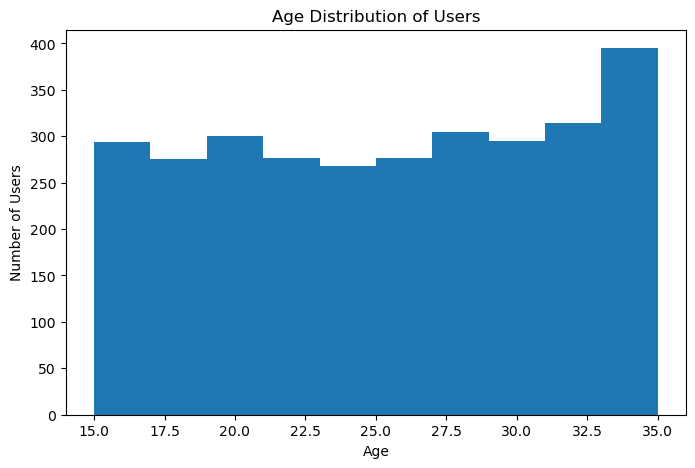

In [9]:
# USERS AGE DISTRIBUTION
plt.figure(figsize=(8,5))
plt.hist(users["Age"],bins=10)
plt.title("Age Distribution of Users")
plt.ylabel("Number of Users")
plt.xlabel("Age")
plt.show()

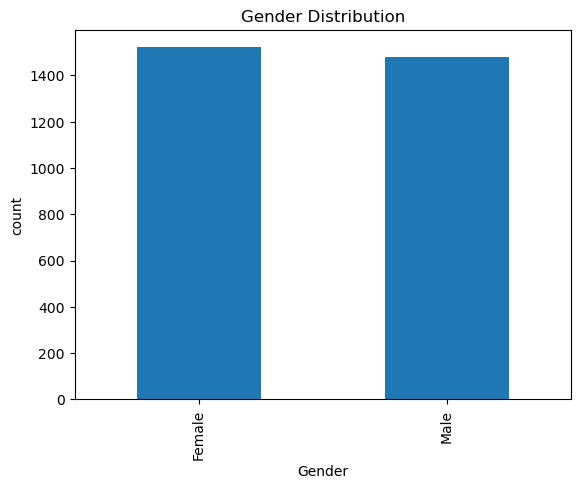

In [25]:
# GENDER DISTRIBUTION
users["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Users")

plt.show()

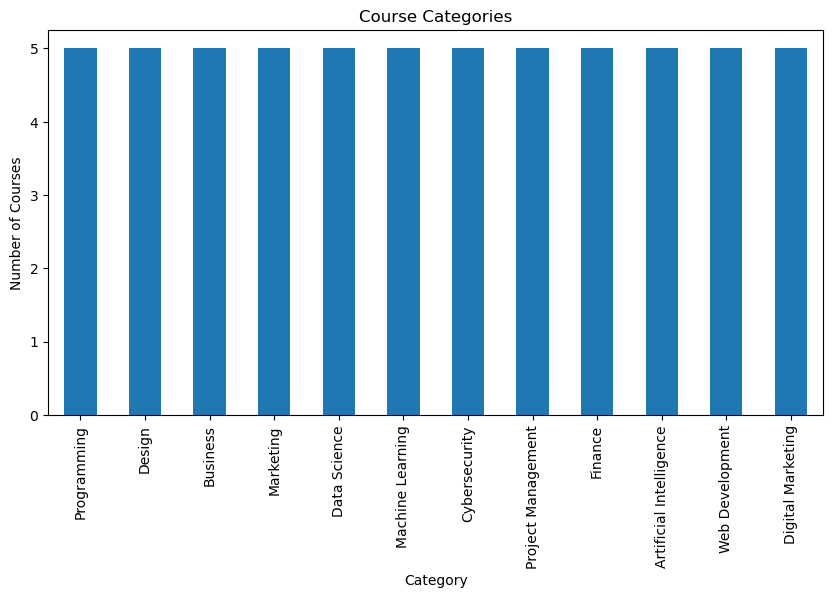

In [10]:
# COURSES CATEGORIES
courses["CourseCategory"].value_counts().plot(kind="bar",figsize=(10,5))

plt.title("Course Categories")
plt.xlabel("Category")
plt.ylabel("Number of Courses")

plt.show()

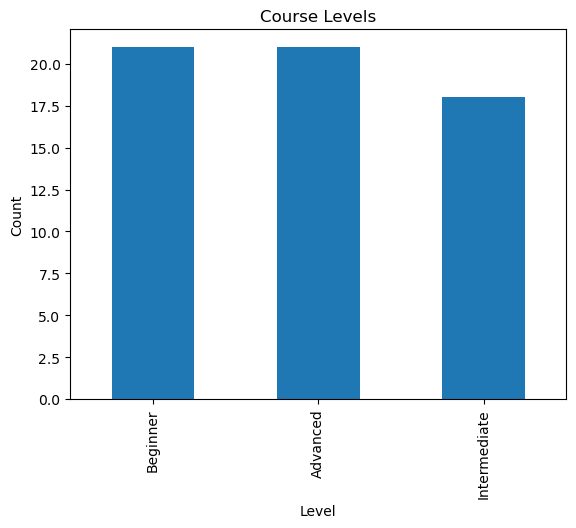

In [11]:
# COURSE LEVELS
courses["CourseLevel"].value_counts().plot(kind="bar")
plt.title("Course Levels")
plt.xlabel("Level")
plt.ylabel("Count")

plt.show()

In [16]:
# MERGE TRANSACTIONS WITH COURSES ON COURSEID
trans_course=transactions.merge(courses,on="CourseID", how="left")
trans_course.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14


In [17]:
trans_course.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    10000 non-null  object        
 1   UserID           10000 non-null  object        
 2   CourseID         10000 non-null  object        
 3   TransactionDate  10000 non-null  datetime64[ns]
 4   Amount           10000 non-null  float64       
 5   PaymentMethod    10000 non-null  object        
 6   TeacherID        10000 non-null  object        
 7   CourseName       10000 non-null  object        
 8   CourseCategory   10000 non-null  object        
 9   CourseType       10000 non-null  object        
 10  CourseLevel      10000 non-null  object        
 11  CoursePrice      10000 non-null  float64       
 12  CourseDuration   10000 non-null  float64       
 13  CourseRating     10000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), objec

In [18]:
#TOTAL COURSES ENROLLED BY EACH USER
total_courses =trans_course.groupby("UserID")["CourseID"].count().reset_index()

total_courses.columns=["UserID","TotalCourses"]

total_courses.head()

,UserID,TotalCourses
0,U00001,1
1,U00002,1
2,U00003,11
3,U00004,13
4,U00005,2


In [19]:
# TOTAL AMOUNT SPENT BY EACH USER

total_amount= trans_course.groupby("UserID")["Amount"].sum().reset_index()

total_amount.columns=["UserID","TotalAmountSpent"]

total_amount.head()

,UserID,TotalAmountSpent
0,U00001,394.26
1,U00002,0.00
2,U00003,613.98
3,U00004,982.05
4,U00005,346.71


In [20]:
# AVERAGE AMOUNT SPENT BY USER

average_amount = trans_course.groupby("UserID")["Amount"].mean().reset_index()

average_amount.columns=("UserID","AverageAmountSpent")

average_amount.head()

,UserID,AverageAmountSpent
0,U00001,394.260000
1,U00002,0.000000
2,U00003,55.816364
3,U00004,75.542308
4,U00005,173.355000


In [21]:
# MERGE ALL THREE TABLES
# CREATE LEARNER PROFILE

learner_profile= total_courses.merge(total_amount,
                                     on="UserID")

learner_profile= learner_profile.merge( average_amount,
                                        on= "UserID")

learner_profile.head()

,UserID,TotalCourses,TotalAmountSpent,AverageAmountSpent
0,U00001,1,394.26,394.260000
1,U00002,1,0.00,0.000000
2,U00003,11,613.98,55.816364
3,U00004,13,982.05,75.542308
4,U00005,2,346.71,173.355000


In [22]:
# PREFERED COURSE CATEGORY
preferred_category=(trans_course.groupby("UserID")["CourseCategory"]
                    .agg(lambda x: x.mode()[0])
                    .reset_index())

preferred_category.columns= ["UserID","PreferredCategory"]

preferred_category.head()

,UserID,PreferredCategory
0,U00001,Cybersecurity
1,U00002,Programming
2,U00003,Marketing
3,U00004,Digital Marketing
4,U00005,Programming


In [23]:
# PREFERED COURSE LEVEL
preferred_level= (trans_course.groupby("UserID")["CourseLevel"]
                .agg(lambda x: x.mode()[0])
                .reset_index())

preferred_level.coulmns= ["UserID","PreferredLevel"]

preferred_level.head()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_33024\3872093479.py:6: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  preferred_level.coulmns= ["UserID","PreferredLevel"]


,UserID,CourseLevel
0,U00001,Intermediate
1,U00002,Beginner
2,U00003,Advanced
3,U00004,Intermediate
4,U00005,Advanced


In [24]:
# AVERAGE COURSE RATING
average_rating=(trans_course.groupby("UserID")["CourseRating"]
                .mean()
                .reset_index())

average_rating.columns= ["UserID","AverageCourseRating"]

average_rating.head()

,UserID,AverageCourseRating
0,U00001,1.350000
1,U00002,2.880000
2,U00003,2.889091
3,U00004,3.451538
4,U00005,2.055000


In [25]:
# DIVERSITY SCORE
diversity_score=(trans_course.groupby("UserID")["CourseCategory"]
                 .nunique()
                 .reset_index())

diversity_score.columns=["UserID","DiversityScore"]

diversity_score.head()

,UserID,DiversityScore
0,U00001,1
1,U00002,1
2,U00003,7
3,U00004,8
4,U00005,2


In [27]:
learner_profile = learner_profile.merge(preferred_category,on="UserID")
learner_profile = learner_profile.merge(preferred_level,on="UserID")
learner_profile = learner_profile.merge(average_rating, on="UserID")
learner_profile = learner_profile.merge(diversity_score,on="UserID")

learner_profile.head()

,UserID,TotalCourses,TotalAmountSpent,AverageAmountSpent,PreferredCategory,CourseLevel,AverageCourseRating,DiversityScore
0,U00001,1,394.26,394.260000,Cybersecurity,Intermediate,1.350000,1
1,U00002,1,0.00,0.000000,Programming,Beginner,2.880000,1
2,U00003,11,613.98,55.816364,Marketing,Advanced,2.889091,7
3,U00004,13,982.05,75.542308,Digital Marketing,Intermediate,3.451538,8
4,U00005,2,346.71,173.355000,Programming,Advanced,2.055000,2


In [26]:
learner_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   UserID              3000 non-null   object 
 1   TotalCourses        3000 non-null   int64  
 2   TotalAmountSpent    3000 non-null   float64
 3   AverageAmountSpent  3000 non-null   float64
dtypes: float64(2), int64(1), object(1)
memory usage: 93.9+ KB


In [28]:
# ADD USER DEMOGRAPHICS

learner_profile = learner_profile.merge(
    users[["UserID", "Age", "Gender"]],
    on="UserID",
    how="left"
)

learner_profile.head()

,UserID,TotalCourses,TotalAmountSpent,AverageAmountSpent,PreferredCategory,CourseLevel,AverageCourseRating,DiversityScore,Age,Gender
0,U00001,1,394.26,394.260000,Cybersecurity,Intermediate,1.350000,1,15,Male
1,U00002,1,0.00,0.000000,Programming,Beginner,2.880000,1,29,Female
2,U00003,11,613.98,55.816364,Marketing,Advanced,2.889091,7,33,Female
3,U00004,13,982.05,75.542308,Digital Marketing,Intermediate,3.451538,8,23,Female
4,U00005,2,346.71,173.355000,Programming,Advanced,2.055000,2,21,Male


In [29]:
learner_profile.isnull().sum()

UserID                 0
TotalCourses           0
TotalAmountSpent       0
AverageAmountSpent     0
PreferredCategory      0
CourseLevel            0
AverageCourseRating    0
DiversityScore         0
Age                    0
Gender                 0
dtype: int64

In [30]:
# CONVERT TEXT INTO NUMBERS
from sklearn.preprocessing import LabelEncoder

In [31]:
label_encoder= LabelEncoder()

In [32]:
learner_profile["Gender"]=label_encoder.fit_transform(
    learner_profile["Gender"])

learner_profile.head()

,UserID,TotalCourses,TotalAmountSpent,AverageAmountSpent,PreferredCategory,CourseLevel,AverageCourseRating,DiversityScore,Age,Gender
0,U00001,1,394.26,394.260000,Cybersecurity,Intermediate,1.350000,1,15,1
1,U00002,1,0.00,0.000000,Programming,Beginner,2.880000,1,29,0
2,U00003,11,613.98,55.816364,Marketing,Advanced,2.889091,7,33,0
3,U00004,13,982.05,75.542308,Digital Marketing,Intermediate,3.451538,8,23,0
4,U00005,2,346.71,173.355000,Programming,Advanced,2.055000,2,21,1


In [33]:
learner_profile.rename(
    columns={"CourseLevel": "PreferredLevel"},
    inplace=True
)

learner_profile.head()

,UserID,TotalCourses,TotalAmountSpent,AverageAmountSpent,PreferredCategory,PreferredLevel,AverageCourseRating,DiversityScore,Age,Gender
0,U00001,1,394.26,394.260000,Cybersecurity,Intermediate,1.350000,1,15,1
1,U00002,1,0.00,0.000000,Programming,Beginner,2.880000,1,29,0
2,U00003,11,613.98,55.816364,Marketing,Advanced,2.889091,7,33,0
3,U00004,13,982.05,75.542308,Digital Marketing,Intermediate,3.451538,8,23,0
4,U00005,2,346.71,173.355000,Programming,Advanced,2.055000,2,21,1


In [34]:
learner_profile["PreferredCategory"] = label_encoder.fit_transform(
    learner_profile["PreferredCategory"]
)

learner_profile.head()

,UserID,TotalCourses,TotalAmountSpent,AverageAmountSpent,PreferredCategory,PreferredLevel,AverageCourseRating,DiversityScore,Age,Gender
0,U00001,1,394.26,394.260000,2,Intermediate,1.350000,1,15,1
1,U00002,1,0.00,0.000000,9,Beginner,2.880000,1,29,0
2,U00003,11,613.98,55.816364,8,Advanced,2.889091,7,33,0
3,U00004,13,982.05,75.542308,5,Intermediate,3.451538,8,23,0
4,U00005,2,346.71,173.355000,9,Advanced,2.055000,2,21,1


In [35]:
learner_profile["PreferredLevel"] = label_encoder.fit_transform(
    learner_profile["PreferredLevel"]
)

learner_profile.head()

,UserID,TotalCourses,TotalAmountSpent,AverageAmountSpent,PreferredCategory,PreferredLevel,AverageCourseRating,DiversityScore,Age,Gender
0,U00001,1,394.26,394.260000,2,2,1.350000,1,15,1
1,U00002,1,0.00,0.000000,9,1,2.880000,1,29,0
2,U00003,11,613.98,55.816364,8,0,2.889091,7,33,0
3,U00004,13,982.05,75.542308,5,2,3.451538,8,23,0
4,U00005,2,346.71,173.355000,9,0,2.055000,2,21,1


In [36]:
learner_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   UserID               3000 non-null   object 
 1   TotalCourses         3000 non-null   int64  
 2   TotalAmountSpent     3000 non-null   float64
 3   AverageAmountSpent   3000 non-null   float64
 4   PreferredCategory    3000 non-null   int64  
 5   PreferredLevel       3000 non-null   int64  
 6   AverageCourseRating  3000 non-null   float64
 7   DiversityScore       3000 non-null   int64  
 8   Age                  3000 non-null   int64  
 9   Gender               3000 non-null   int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 234.5+ KB


In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
X = learner_profile.drop("UserID", axis=1)

X.head()

,TotalCourses,TotalAmountSpent,AverageAmountSpent,PreferredCategory,PreferredLevel,AverageCourseRating,DiversityScore,Age,Gender
0,1,394.26,394.260000,2,2,1.350000,1,15,1
1,1,0.00,0.000000,9,1,2.880000,1,29,0
2,11,613.98,55.816364,8,0,2.889091,7,33,0
3,13,982.05,75.542308,5,2,3.451538,8,23,0
4,2,346.71,173.355000,9,0,2.055000,2,21,1


In [39]:
scaler = StandardScaler()

In [40]:
X_scaled = scaler.fit_transform(X)

In [41]:
X_scaled.shape

(3000, 9)

In [42]:
X_scaled[:5]

array([[-0.53622296,  0.18756061,  2.43865773, -0.72851906,  1.53184351,
        -1.87732837, -0.57838136, -1.64988625,  1.01342342],
       [-0.53622296, -0.62967131, -0.71456607,  1.33082948,  0.2510379 ,
        -0.2668106 , -0.57838136,  0.66589835, -0.98675438],
       [ 1.76187544,  0.64300168, -0.26815638,  1.03663683, -1.02976771,
        -0.25724128,  1.62171679,  1.32755109, -0.98675438],
       [ 2.22149512,  1.40594632, -0.11039166,  0.15405888,  1.53184351,
         0.33480564,  1.98839982, -0.32658077, -0.98675438],
       [-0.30641312,  0.08899779,  0.67189746,  1.33082948, -1.02976771,
        -1.13522705, -0.21169833, -0.65740714,  1.01342342]])

In [43]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [44]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

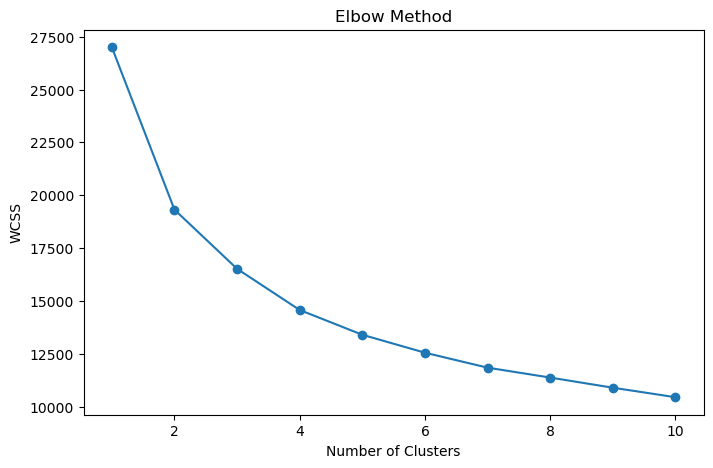

In [45]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [46]:
# FINAL K-MEANS MODEL

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

learner_profile["Cluster"] = kmeans.fit_predict(X_scaled)

learner_profile.head()

,UserID,TotalCourses,TotalAmountSpent,AverageAmountSpent,PreferredCategory,PreferredLevel,AverageCourseRating,DiversityScore,Age,Gender,Cluster
0,U00001,1,394.26,394.260000,2,2,1.350000,1,15,1,3
1,U00002,1,0.00,0.000000,9,1,2.880000,1,29,0,2
2,U00003,11,613.98,55.816364,8,0,2.889091,7,33,0,1
3,U00004,13,982.05,75.542308,5,2,3.451538,8,23,0,1
4,U00005,2,346.71,173.355000,9,0,2.055000,2,21,1,0


In [47]:
learner_profile["Cluster"].value_counts()

Cluster
2    1042
0     995
3     511
1     452
Name: count, dtype: int64

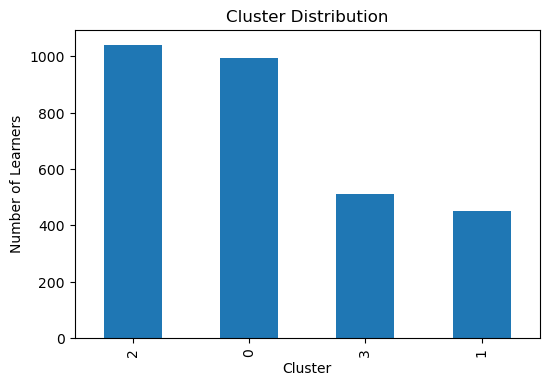

In [48]:
learner_profile["Cluster"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Learners")

plt.show()

In [49]:
cluster_summary = learner_profile.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,TotalCourses,TotalAmountSpent,AverageAmountSpent,PreferredCategory,PreferredLevel,AverageCourseRating,DiversityScore,Age,Gender
Cluster,,,,,,,,,
0,1.542714,54.305126,26.405533,4.992965,0.762814,3.192665,1.483417,25.004020,1.000000
1,13.420354,1252.527146,93.530362,3.694690,0.688053,3.114369,8.745575,24.924779,0.493363
2,1.595969,67.601392,31.335967,4.938580,0.814779,3.167908,1.525912,25.078695,0.000000
3,1.440313,431.911840,326.484796,3.219178,0.964775,2.964889,1.395303,24.747554,0.512720


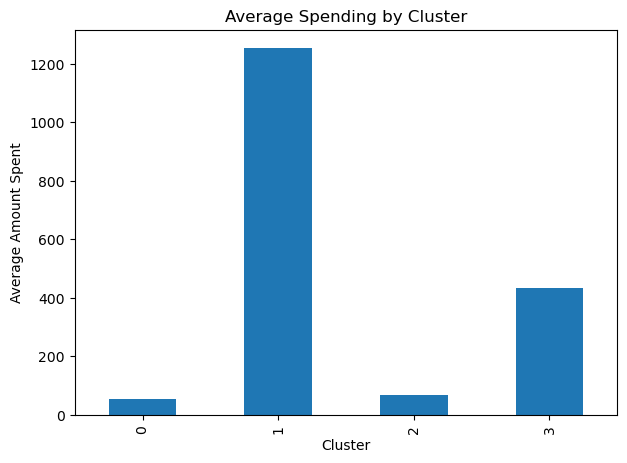

In [50]:
cluster_summary["TotalAmountSpent"].plot(kind="bar", figsize=(7,5))

plt.title("Average Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Amount Spent")

plt.show()

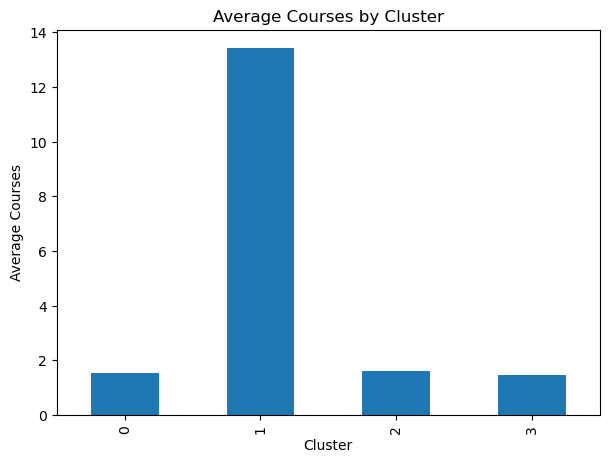

In [51]:
cluster_summary["TotalCourses"].plot(kind="bar", figsize=(7,5))

plt.title("Average Courses by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Courses")

plt.show()

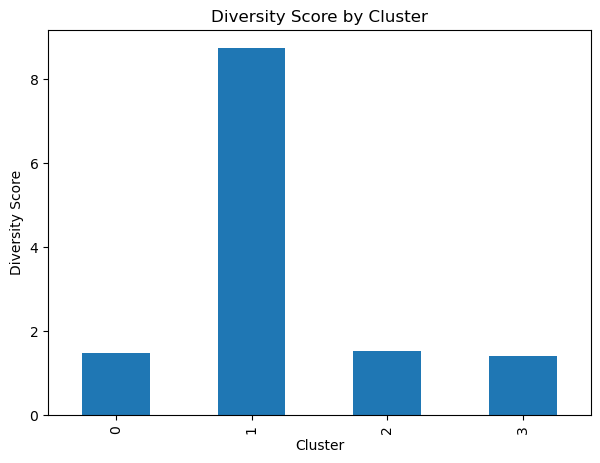

In [52]:
cluster_summary["DiversityScore"].plot(kind="bar", figsize=(7,5))

plt.title("Diversity Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Diversity Score")

plt.show()

In [53]:
cluster_names = {
    0: "Casual Learners",
    1: "Power Learners",
    2: "New Learners",
    3: "Premium Learners"
}

learner_profile["ClusterName"] = learner_profile["Cluster"].map(cluster_names)

learner_profile.head()

,UserID,TotalCourses,TotalAmountSpent,AverageAmountSpent,PreferredCategory,PreferredLevel,AverageCourseRating,DiversityScore,Age,Gender,Cluster,ClusterName
0,U00001,1,394.26,394.260000,2,2,1.350000,1,15,1,3,Premium Learners
1,U00002,1,0.00,0.000000,9,1,2.880000,1,29,0,2,New Learners
2,U00003,11,613.98,55.816364,8,0,2.889091,7,33,0,1,Power Learners
3,U00004,13,982.05,75.542308,5,2,3.451538,8,23,0,1,Power Learners
4,U00005,2,346.71,173.355000,9,0,2.055000,2,21,1,0,Casual Learners


In [54]:
from sklearn.metrics import silhouette_score

In [55]:
score = silhouette_score(X_scaled, learner_profile["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.21117980905070186


In [56]:
recommendations = courses.groupby("CourseCategory")["CourseRating"].mean().sort_values(ascending=False)

recommendations

CourseCategory
Marketing                  3.722
Digital Marketing          3.656
Data Science               3.316
Design                     3.162
Project Management         3.142
Artificial Intelligence    3.036
Programming                3.036
Finance                    3.010
Cybersecurity              2.902
Web Development            2.846
Business                   2.688
Machine Learning           2.658
Name: CourseRating, dtype: float64

In [57]:
top_categories = recommendations.head(5)

print(top_categories)

CourseCategory
Marketing             3.722
Digital Marketing     3.656
Data Science          3.316
Design                3.162
Project Management    3.142
Name: CourseRating, dtype: float64


In [58]:
def recommend_courses(cluster):

    if cluster == 0:
        return "Programming, Data Science"

    elif cluster == 1:
        return "Machine Learning, Artificial Intelligence"

    elif cluster == 2:
        return "Beginner Programming, Web Development"

    else:
        return "Cybersecurity, Cloud Computing"

In [59]:
learner_profile["Recommendation"] = learner_profile["Cluster"].apply(recommend_courses)

learner_profile.head()

,UserID,TotalCourses,TotalAmountSpent,AverageAmountSpent,PreferredCategory,PreferredLevel,AverageCourseRating,DiversityScore,Age,Gender,Cluster,ClusterName,Recommendation
0,U00001,1,394.26,394.260000,2,2,1.350000,1,15,1,3,Premium Learners,"Cybersecurity, Cloud Computing"
1,U00002,1,0.00,0.000000,9,1,2.880000,1,29,0,2,New Learners,"Beginner Programming, Web Development"
2,U00003,11,613.98,55.816364,8,0,2.889091,7,33,0,1,Power Learners,"Machine Learning, Artificial Intelligence"
3,U00004,13,982.05,75.542308,5,2,3.451538,8,23,0,1,Power Learners,"Machine Learning, Artificial Intelligence"
4,U00005,2,346.71,173.355000,9,0,2.055000,2,21,1,0,Casual Learners,"Programming, Data Science"


In [60]:
learner_profile.to_csv("Learner_Segmentation_Output.csv", index=False)

In [62]:
import os

print(os.getcwd())

C:\Users\lenovo


In [63]:
learner_profile.to_csv(r"C:\Users\lenovo\Desktop\Learner_Segmentation_Output.csv", index=False)